# Proyecto Módulo 8 – Clasificador Inteligente de Imágenes de Ropa (Keras/TensorFlow)

Este notebook desarrolla las 4 lecciones del proyecto usando **Keras/TensorFlow**:
1. Red neuronal densa simple (clasificación binaria).
2. Discusión de arquitecturas (densa vs convolutiva).
3. Implementación de modelo denso para Fashion-MNIST.
4. Implementación de CNN para Fashion-MNIST y comparación.

Dataset: Fashion-MNIST (28x28, 10 clases de ropa).

In [27]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

print(tf.__version__)

2.20.0


In [28]:
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

x_train.shape, y_train.shape, x_test.shape, y_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

In [29]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train_flat = x_train.reshape(-1, 28 * 28)
x_test_flat = x_test.reshape(-1, 28 * 28)

class_names = [
    "Camiseta/top", "Pantalón", "Suéter", "Vestido", "Abrigo",
    "Sandalia", "Camisa", "Zapatilla", "Bolso", "Botín"
]

len(class_names)

10

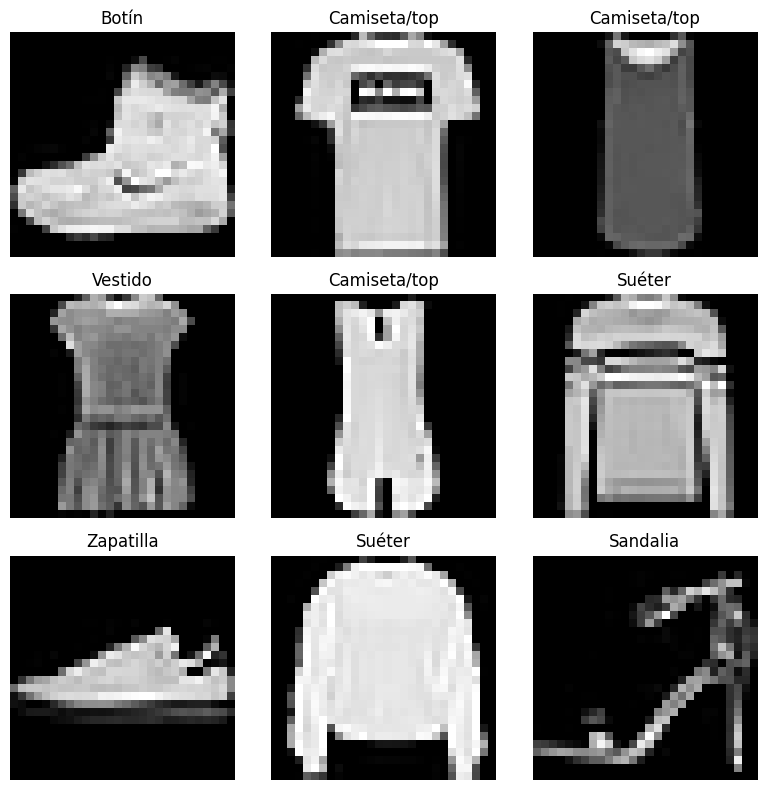

In [30]:
plt.figure(figsize=(8, 8))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.axis("off")
plt.tight_layout()
plt.show()

In [31]:
binary_train_mask = (y_train == 7) | (y_train == 9)
binary_test_mask = (y_test == 7) | (y_test == 9)

x_train_bin = x_train_flat[binary_train_mask]
y_train_bin = (y_train[binary_train_mask] == 7).astype(int)

x_test_bin = x_test_flat[binary_test_mask]
y_test_bin = (y_test[binary_test_mask] == 7).astype(int)

x_train_bin.shape, x_test_bin.shape

((12000, 784), (2000, 784))

## Lección 1 – Arquitectura de red densa (binaria)

1. **Capa de entrada**: vector de tamaño 784 (28x28 píxeles aplanados).
2. **Capa oculta densa**: por ejemplo 128 neuronas con activación ReLU.
3. **Capa de salida**: 1 neurona con activación sigmoide (da un valor entre 0 y 1 que interpretamos como probabilidad de "zapatilla").

- Función de pérdida: `binary_crossentropy` (para clasificación binaria).
- Optimizador: `adam` (simple y efectivo).
- Métrica: `accuracy`.

In [32]:
model_bin = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(128, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model_bin.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 100,609 (393.00 KB)

 Trainable params: 100,609 (393.00 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
model_bin.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

In [34]:
history_bin = model_bin.fit(
    x_train_bin,
    y_train_bin,
    validation_split=0.2,
    epochs=10,
    batch_size=128,
    verbose=1
)

Epoch 1/10


75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9150 - loss: 0.2137 - val_accuracy: 0.9325 - val_loss: 0.1550
Epoch 2/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9506 - loss: 0.1331 - val_accuracy: 0.9554 - val_loss: 0.1305
Epoch 3/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9595 - loss: 0.1121 - val_accuracy: 0.9517 - val_loss: 0.1426
Epoch 4/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9579 - loss: 0.1085 - val_accuracy: 0.9646 - val_loss: 0.1086
Epoch 5/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9624 - loss: 0.0980 - val_accuracy: 0.9513 - val_loss: 0.1199
Epoch 6/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9638 - loss: 0.0930 - val_accuracy: 0.9667 - val_loss: 0.1147
Epoch 7/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9666 - loss: 0.0885 - val_accuracy: 0.9683 - val_loss: 0.1052
Epoch 8/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9701 - loss: 0.0781 - val_accuracy: 0.9625 - val_loss: 0.1011
Epo

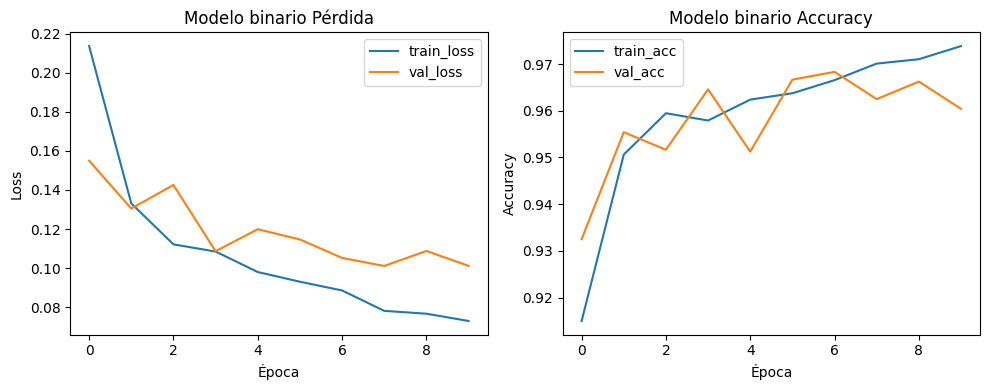

In [35]:
def plot_history(h, title_prefix=""):
    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.plot(h.history["loss"], label="train_loss")
    plt.plot(h.history["val_loss"], label="val_loss")
    plt.title(f"{title_prefix} Pérdida")
    plt.xlabel("Época")
    plt.ylabel("Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(h.history["accuracy"], label="train_acc")
    plt.plot(h.history["val_accuracy"], label="val_acc")
    plt.title(f"{title_prefix} Accuracy")
    plt.xlabel("Época")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(history_bin, title_prefix="Modelo binario")

In [36]:
test_loss_bin, test_acc_bin = model_bin.evaluate(x_test_bin, y_test_bin, verbose=0)
print("Pérdida (test):", test_loss_bin)
print("Accuracy (test):", test_acc_bin)

idx = 0
sample = x_test_bin[idx:idx+1]
pred_prob = model_bin.predict(sample)[0, 0]
pred_label = int(pred_prob >= 0.5)
print("Prob. zapatilla:", pred_prob)
print("Predicción (1=zapatilla,0=botín):", pred_label)
print("Etiqueta real:", y_test_bin[idx])

Pérdida (test): 0.10061480104923248
Accuracy (test): 0.9624999761581421
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
Prob. zapatilla: 0.01864469
Predicción (1=zapatilla,0=botín): 0
Etiqueta real: 0


## Lección 2 – Red densa vs CNN

- **Red densa**: conecta todas las neuronas de una capa con todas las de la siguiente, no aprovecha la estructura espacial de la imagen.
- **CNN**: usa filtros pequeños que se desplazan sobre la imagen, detectando patrones locales y reutilizándolos en toda la imagen.

Usaremos un modelo denso como línea base y una CNN para mejorar el desempeño y compararlos.

In [37]:
model_dense = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(10, activation="softmax")
])

model_dense.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

In [38]:
model_dense.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

In [39]:
history_dense = model_dense.fit(
    x_train_flat,
    y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=256,
    verbose=1
)

Epoch 1/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.7435 - loss: 0.7267 - val_accuracy: 0.8400 - val_loss: 0.4474
Epoch 2/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8342 - loss: 0.4688 - val_accuracy: 0.8587 - val_loss: 0.3881
Epoch 3/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8509 - loss: 0.4155 - val_accuracy: 0.8602 - val_loss: 0.3716
Epoch 4/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8614 - loss: 0.3852 - val_accuracy: 0.8713 - val_loss: 0.3525
Epoch 5/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8660 - loss: 0.3666 - val_accuracy: 0.8797 - val_loss: 0.3376
Epoch 6/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8712 - loss: 0.3524 - val_accuracy: 0.8757 - val_loss: 0.3374
Epoch 7/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8768 - loss: 0.3374 - val_accuracy: 0.8820 - val_loss: 0.3242
Epoch 8/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8791 - loss: 0.3273 - val_accuracy

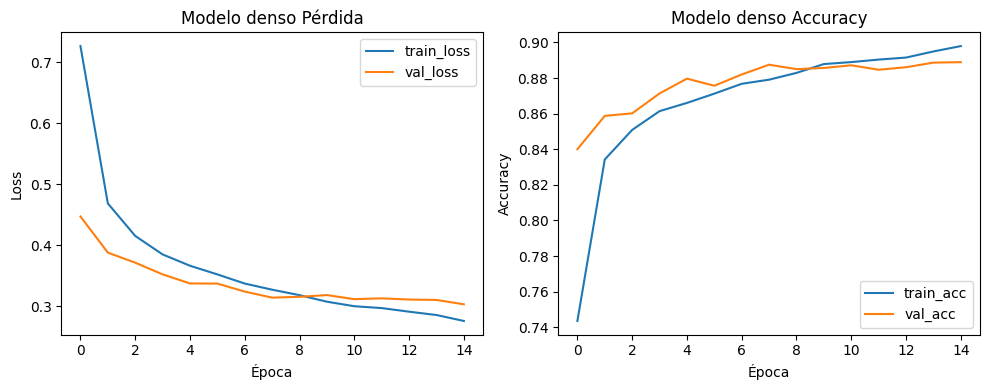

Pérdida (test) denso: 0.3286314308643341
Accuracy (test) denso: 0.883899986743927


In [40]:
plot_history(history_dense, title_prefix="Modelo denso")

test_loss_dense, test_acc_dense = model_dense.evaluate(x_test_flat, y_test, verbose=0)
print("Pérdida (test) denso:", test_loss_dense)
print("Accuracy (test) denso:", test_acc_dense)

In [41]:
x_train_cnn = x_train[..., np.newaxis]
x_test_cnn = x_test[..., np.newaxis]

x_train_cnn.shape, x_test_cnn.shape

((60000, 28, 28, 1), (10000, 28, 28, 1))

In [42]:
model_cnn = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model_cnn.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [43]:
model_cnn.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

history_cnn = model_cnn.fit(
    x_train_cnn,
    y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=256,
    verbose=1
)

Epoch 1/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - accuracy: 0.7555 - loss: 0.6921 - val_accuracy: 0.8442 - val_loss: 0.4353
Epoch 2/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step - accuracy: 0.8397 - loss: 0.4400 - val_accuracy: 0.8674 - val_loss: 0.3735
Epoch 3/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - accuracy: 0.8590 - loss: 0.3897 - val_accuracy: 0.8763 - val_loss: 0.3443
Epoch 4/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - accuracy: 0.8698 - loss: 0.3585 - val_accuracy: 0.8873 - val_loss: 0.3192
Epoch 5/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 7s 38ms/step - accuracy: 0.8771 - loss: 0.3385 - val_accuracy: 0.8918 - val_loss: 0.3049
Epoch 6/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.8824 - loss: 0.3180 - val_accuracy: 0.8976 - val_loss: 0.2876
Epoch 7/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.8883 - loss: 0.3039 - val_accuracy: 0.9012 - val_loss: 0.2776
Epoch 8/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.8929 - loss: 0.2918 - val_acc

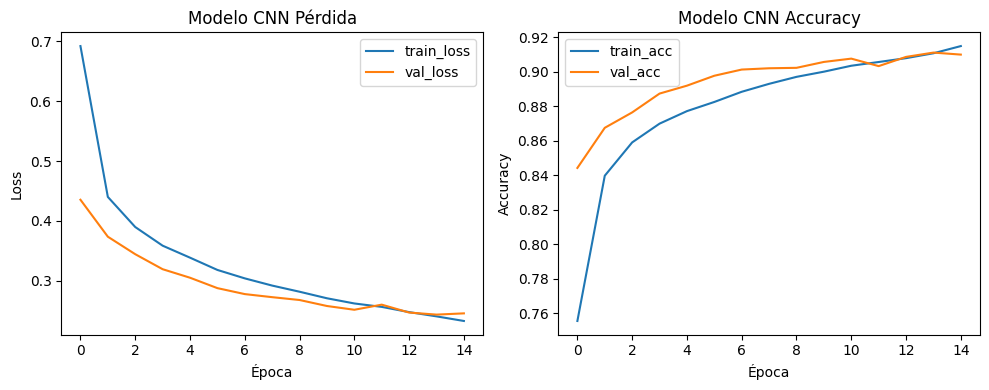

Pérdida (test) CNN: 0.2601413428783417
Accuracy (test) CNN: 0.9027000069618225
Accuracy denso vs CNN: 0.883899986743927 vs 0.9027000069618225


In [44]:
plot_history(history_cnn, title_prefix="Modelo CNN")

test_loss_cnn, test_acc_cnn = model_cnn.evaluate(x_test_cnn, y_test, verbose=0)
print("Pérdida (test) CNN:", test_loss_cnn)
print("Accuracy (test) CNN:", test_acc_cnn)
print("Accuracy denso vs CNN:", test_acc_dense, "vs", test_acc_cnn)

In [45]:
from PIL import Image

def predict_external_image(path, model, use_cnn=True):
    img = Image.open(path).convert("L").resize((28, 28))
    img_array = np.array(img).astype("float32") / 255.0

    if use_cnn:
        img_array = img_array[np.newaxis, ..., np.newaxis]
    else:
        img_array = img_array.reshape(1, 28 * 28)

    probs = model.predict(img_array)[0]
    pred_class = int(np.argmax(probs))
    print("Predicción:", class_names[pred_class])
    print("Probabilidades:", probs)

# Ejemplo de uso:
predict_external_image("camisa.png", model_cnn, use_cnn=True)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
Predicción: Bolso
Probabilidades: [1.1578577e-02 1.0632575e-04 7.2936714e-02 6.0713885e-04 1.2451016e-04
 1.3658689e-05 9.4222771e-03 3.8302431e-05 9.0373057e-01 1.4417992e-03]
